### __Group Assignment - Predicting Airbnb Listing Prices in Melbourne, Australia__

--- 

**Kaggle Competition Ends:** Friday, 6 June 2025 @ 3:00pm (Week 13)  
**Assignment Due Date on iLearn:** Friday, 6 June 2025 @ 11.55pm (Week 13)   
**Total Marks:** 30

**Overview:**   

- In the group assignment you will form a team of 3 students and participate in a forecasting competition on Kaggle


**Instructions:** 

- Form a team of 3 students 
- Each team member needs to join [https://www.kaggle.com](https://www.kaggle.com/)  
- Choose a team leader and form a team on Kaggle [https://www.kaggle.com/t/fc5974a56165cea945ee1ec182b079af](https://www.kaggle.com/t/fc5974a56165cea945ee1ec182b079af)
    - Team leader to click on `team` and invite other 2 team members to join
    - Your **team's name must start** with our unit code
- All team members should work on all the tasks however   
    - Each team member will be responsible for one of the 3 tasks listed below    
- **Your predictions must be generated by a model you develop here** 
    - You will receive a mark of **zero** if your code is not able produce the forecasts you submit to Kaggle 

**Competition Rankings**

The rankings for the competition are determined through two different leaderboards:

- **Public Leaderboard Ranking**: Available during the competition, these rankings are calculated based on 50% of the test dataset, which includes 1,500 observations. This allows participants to see how they are performing while the competition is still ongoing.
- **Final Leaderboard Ranking**: These rankings are recalculated from the other 50% of the test dataset, which consists of the remaining 1,500 observations, and are revealed 5 minutes after the competition concludes. This final evaluation determines the ultimate standings of the competition.



**Marks** 

- Assignment: 30 marks consisting of Solutions (27 marks) + Video Presentation (3 marks)
- **Each Student's Mark: 50% x overall assignment mark + 50% x mark for the task that you are responsible for**  



**Submissions:**  

1. On Kaggle: submit your team's forecast in order to be ranked by Kaggle
2. On iLearn **only team leader to submit** the assignment Jupyter notebook re-named to your team's name on Kaggle   
    - The Jupyter notebook must contain team members names/ID numbers, and the group name Kaggle
    - One 15 minute video recording of your work 
        - 5 marks will be deducted from each Task for which there is no video presentation   


---
---

### <span style="background-color: yellow;">**Fill out the following information**

- Team Name on Kaggle: `BUSA8001-THT`
- Team Leader and Team Member 1: `Cao Thuc Ta 48382590`
- Team Member 2: `Doan Truong Le 47828102`
- Team Member 3: `Duc Huy Tran 48477192`

---

## Task 1: Problem Description and Initial Data Analysis

- You must clearly explain all your answers in both the Markdown file and the recorded video.

**Total Marks: 9**   

Based on the Competition Overview, datasets and additional information provided on Kaggle, along with insights gained from personal research of the topic, write **Problem Description** (about 500 words) focusing on the sections listed below: 
1. Forecasting Problem - explain what we are trying to do and how it could be used in the real world, e.g. who and how may benefit from it (2 marks)    
2. Evaluation Criteria - discuss the criterion that is used in this competition to assess forecasting performance, and its pros and cons. (2 marks)     
3. Categorise all variables provided in the dataset according to their type; Hint: similar to what we had in Programming Task 1 (2 marks)  
4. Missing Values - explain what you find for both the training and test datasets at this stage (2 marks)
5. Provide and discuss some interesting *univariate* data characteristics (e.g. summary statistics and plots) in the training dataset  (1 marks)       
- Hints:
    - You should **not** discuss any specific predictive algorithms at this stage


Student in charge of this task: `Doan Truong Le 47828102`

### 1. Forecasting Problem

The objective of this project is to develop a model that can accurately predict the prices of Airbnb listings in Melbourne, Australia, based on various listing characteristics. In a real-world context, such a forecasting system has practical value for multiple parties involved in the short-term rental ecosystem.

For individual hosts or homeowners, accurate price forecasting provides a benchmark to set competitive yet profitable nightly rates. By understanding how different factors — such as property type, room features, amenities, and location — influence pricing, hosts can optimise their listings to meet market expectations and maximise occupancy and revenue.

For the Airbnb platform itself, forecasting supports dynamic pricing, promotional strategies, and broader market analysis. It enables Airbnb to offer price recommendations, detect anomalies, and tailor services to match consumer demand trends.

From the perspective of renters or travellers, price insights help plan vacations or long-term stays more effectively. Forecasting gives customers realistic expectations for accommodation costs, aiding in budget planning and decision-making.

### 2. Evaluation Criteria

In this competition, the model's accuracy is measured using **Mean Absolute Error (MAE)**. MAE calculates the average of the absolute differences between the predicted values and the actual values of the target variable, which is the listing price. It provides a straightforward measure of how close predictions are to the true outcomes.

MAE is particularly useful because it expresses errors in the same unit as the target, making it easy to interpret. For example, a MAE of 25 means that, on average, predictions are off by 25 dollars.

Compared to other metrics like **Root Mean Squared Error (RMSE)**, MAE does not square the error terms. This means MAE treats all errors equally, whereas RMSE penalizes larger errors more heavily. MAE is therefore more robust to outliers, while RMSE is more sensitive to them.

For this reason, MAE is a fair and balanced choice for evaluating Airbnb price predictions, where large errors may not necessarily be worse than frequent smaller ones.

### 3. Categorise All Variables

The dataset features have been classified into five main types based on the metadata file and data inspection. Numerical variables include both `integer` and `numeric` types. Ten columns with previously undefined types were carefully reviewed using the training data and are now accurately classified.

#### Table: Variable Classification Summary

| Variable Type         | Number of Features | Example Feature Names                                       |
|------------------------|--------------------|-------------------------------------------------------------|
| **Numerical**          | 34                 | `price`, `latitude`, `accommodates`, `review_scores_rating` |
| **Text/Categorical**   | 17                 | `room_type`, `host_response_time`, `property_type`          |
| **Boolean**            | 5                  | `host_is_superhost`, `has_availability`                     |
| **Date/Time**          | 3                  | `host_since`, `first_review`, `last_review`                 |

#### Description:
- **Numerical variables** include continuous and discrete values like price, coordinates, and scores.
- **Categorical variables** are non-numeric text features or labels, including structured text responses.
- **Boolean variables** represent binary yes/no values.
- **Date/Time variables** track hosting and review history.

> **Note**: Ten variables were originally missing a type label in the metadata. These have been reviewed based on the data content and are now included in the appropriate categories above (e.g., `host_acceptance_rate` as numerical, `host_response_time` as categorical).

### 4. Missing Values

In [3]:
import pandas as pd

# Load datasets
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# Calculate missing values
missing_train = train.isnull().sum()
missing_test = test.isnull().sum()

# Filter only columns with missing values
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)

# Display top 5 columns with missing values
print("Top missing columns in train dataset:")
print(missing_train.head(5))
print("\nTop missing columns in test dataset:")
print(missing_test.head(5))

Top missing columns in train dataset:
host_neighbourhood       3460
host_about               2270
neighbourhood            1823
neighborhood_overview    1823
host_location            1280
dtype: int64

Top missing columns in test dataset:
host_neighbourhood       2066
host_about               1441
neighbourhood            1424
neighborhood_overview    1424
host_location             770
dtype: int64


The training and test datasets both contain missing values, primarily in descriptive and location-related fields. We used Python to identify the top columns with the highest number of missing values.

In the **training set**, the most affected columns are:
- `host_neighbourhood`: 3,460 missing
- `host_about`: 2,270 missing
- `neighbourhood` and `neighborhood_overview`: 1,823 missing each
- `host_location`: 1,280 missing

In the **test set**, the same variables are missing in similar proportions:
- `host_neighbourhood`: 2,066 missing
- `host_about`: 1,441 missing
- `neighbourhood` and `neighborhood_overview`: 1,424 missing each
- `host_location`: 770 missing

These columns are mostly free-text fields and may be excluded or imputed depending on their relevance and the modeling strategy.

### 5. Univariate Characteristics

               price  accommodates  number_of_reviews  availability_365
count    7000.000000   7000.000000        7000.000000       6953.000000
mean      285.649714      3.839714          68.265429        177.845822
std      2325.453324      2.514657          83.903280        125.799953
min        25.000000      1.000000           1.000000          0.000000
25%       117.000000      2.000000          13.000000         65.000000
50%       172.000000      4.000000          38.000000        161.000000
75%       268.000000      5.000000          92.000000        311.000000
max    145160.000000     16.000000         836.000000        365.000000
Skewness of price: 50.41


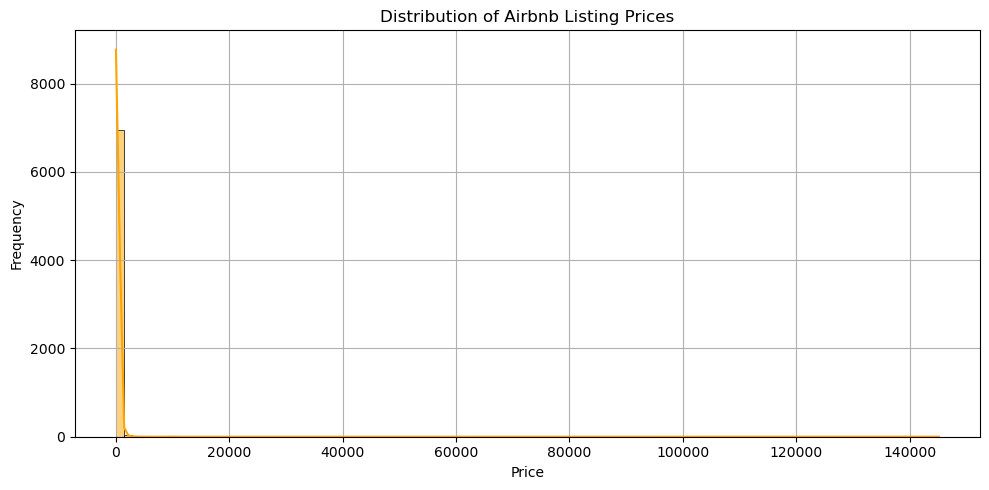

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean the price column
train = pd.read_csv("train.csv")
train['price'] = train['price'].replace(r'[\$,]', '', regex=True).astype(float)

# Summary statistics
summary = train[['price', 'accommodates', 'number_of_reviews', 'availability_365']].describe()
print(summary)

# Skewness of the price distribution
price_skew = train['price'].skew()
print(f"Skewness of price: {price_skew:.2f}")

# Plot price distribution
plt.figure(figsize=(10, 5))
sns.histplot(train['price'], bins=100, kde=True, color='orange')
plt.title("Distribution of Airbnb Listing Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

The target variable `price` displays a highly right-skewed distribution (skewness ≈ 50.4), indicating the presence of significant outliers or luxury listings with extremely high prices. Most listings are priced under **AUD 500**, while a few are listed above **AUD 10,000**, as shown in the histogram.

From the summary statistics, we observe:

- `accommodates` has a mean of 3.84 and a maximum of 16, suggesting listings range from small rooms to large homes.
- `number_of_reviews` varies widely, with some listings receiving over 800 reviews, which points to a long listing lifespan or high demand.
- `availability_365` ranges from 0 to 365, showing that some listings are available all year while others are seasonal.

These characteristics highlight potential needs for scaling and transformation to ensure models do not become biassed due to extreme values or inconsistent distributions.

---

## Task 2: Data Cleaning, Missing Observations and Feature Engineering

- You must clearly explain all your answers in both the Markdown file and the recorded video. 

**Total Marks: 9**

Student in charge of this task: `Cao Thuc Ta 48382590`

In [5]:
import numpy as np, pandas as pd
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

pd.set_option('display.max_rows', None, 'display.max_columns', None, 'display.width', None) 

In [6]:
train.head()

,ID,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price
0,0,city scrape,"The Stables, Richmond",Superbly located hotel style accommodation in ...,Richmond is a great neighbourhood. A beautifu...,Ione,2013-03-16,"Melbourne, Australia",I'm a working mum who loves being able to shar...,within an hour,100%,98%,f,Richmond,2.0,"['email', 'phone']",t,t,"Richmond, Victoria, Australia",Yarra,-37.82030,144.99016,Entire guesthouse,Entire home/apt,2,1 bath,1.0,1.0,"[""Sukin conditioner"", ""Extra pillows and blank...",2,14,2.0,2,1125,1125.0,2.0,1125.0,t,0,0,0,12.0,741,37,1,2013-03-29,2023-02-18,4.88,4.91,4.97,4.94,4.93,4.93,4.82,f,2,2,0,0,6.11,$132.00
1,1,city scrape,Room in Cool Deco Apartment in Brunswick East,A large air conditioned room with firm queen s...,This hip area is a crossroads between two grea...,Lindsay,2009-09-16,"Melbourne, Australia",As an artist working in animation and video I ...,within a few hours,100%,98%,f,Brunswick,1.0,"['email', 'phone']",t,t,"Brunswick East, Victoria, Australia",Moreland,-37.76606,144.97951,Private room in rental unit,Private room,2,1 shared bath,1.0,1.0,"[""Extra pillows and blankets"", ""Laundromat nea...",4,27,4.0,4,27,27.0,4.0,27.0,t,0,12,22,112.0,169,25,3,2013-01-12,2023-03-08,4.48,4.64,3.97,4.72,4.69,4.65,4.60,f,1,0,1,0,1.37,$39.00
2,2,city scrape,The Suite @ Angelus Retreat,<b>The space</b><br />Welcome to ANGELUS Retre...,NaN,Margaret Jiin,2011-11-28,"Melbourne, Australia",I have very special interests in Life and Life...,within a few hours,100%,78%,t,NaN,2.0,"['email', 'phone']",t,t,NaN,Yarra Ranges,-37.90546,145.39447,Entire rental unit,Entire home/apt,4,2.5 baths,2.0,4.0,"[""Microwave"", ""Hot tub"", ""Conditioner"", ""Smoke...",2,365,2.0,2,365,365.0,2.0,365.0,t,30,60,90,365.0,8,2,0,2015-07-06,2022-06-13,4.75,4.88,4.75,4.88,4.50,5.00,4.75,f,2,2,0,0,0.09,$270.00
3,3,city scrape,Million Dollar Views Over Melbourne,<b>The space</b><br /><b>Enjoy Million Dollar ...,NaN,Paul,2010-06-13,"Melbourne, Australia",Professional couple who enjoy entertaining in ...,within a day,75%,92%,f,Southbank,4.0,"['email', 'phone']",t,t,NaN,Melbourne,-37.82163,144.96672,Private room in rental unit,Private room,2,2.5 baths,1.0,1.0,"[""Hot tub"", ""Gym"", ""Washer"", ""Dryer"", ""Kitchen...",1,730,1.0,1,730,730.0,1.0,730.0,t,30,60,90,365.0,2,0,0,2011-10-16,2012-01-27,4.50,4.00,4.50,4.00,4.00,5.00,4.00,f,1,0,1,0,0.01,"$1,000.00"
4,4,city scrape,Melbourne - Old Trafford Apartment,After hosting many guests from all over the wo...,Our street is quiet & secluded but within walk...,Daryl & Dee,2010-07-12,"Berwick, Australia",We are an active couple who work from home and...,within a few hours,100%,87%,t,NaN,1.0,"['email', 'phone', 'work_email']",t,t,"Berwick, Victoria, Australia",NaN,-38.05725,145.33936,Entire rental unit,Entire home/apt,5,1 bath,3.0,3.0,"[""Laundromat nearby"", ""Private patio or balcon...",1,14,1.0,1,14,14.0,1.0,14.0,t,17,21,51,312.0,214,39,4,2010-11-24,2023-03-03,4

In [7]:
# Extract necessary features for regression models 
train = train[['host_since','host_response_time', 'host_response_rate',	'host_acceptance_rate',	'host_is_superhost', 'host_listings_count',	'host_verifications', 'host_has_profile_pic',	'host_identity_verified', 'neighbourhood_cleansed',	'latitude',	'longitude', 
               'property_type', 'room_type', 'accommodates', 'bathrooms','bedrooms','beds', 'amenities', 'minimum_nights','maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',
                'availability_30', 'availability_90',	'availability_365',	'number_of_reviews','number_of_reviews_ltm','number_of_reviews_l30d', 'last_review','review_scores_rating',
                'review_scores_accuracy', 'review_scores_cleanliness',	'review_scores_checkin','review_scores_communication',	'review_scores_location', 'review_scores_value','instant_bookable',	'calculated_host_listings_count',	
                'calculated_host_listings_count_entire_homes','calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month','price'
]]

test = test[['host_since','host_response_time', 'host_response_rate',	'host_acceptance_rate',	'host_is_superhost', 'host_listings_count',	'host_verifications','host_has_profile_pic',	'host_identity_verified', 'neighbourhood_cleansed',	'latitude',	'longitude', 
               'property_type', 'room_type', 'accommodates', 'bathrooms','bedrooms','beds', 'amenities', 'minimum_nights','maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',
                'availability_30', 'availability_90', 'availability_365', 'number_of_reviews','number_of_reviews_ltm','number_of_reviews_l30d', 'last_review','review_scores_rating',
                'review_scores_accuracy', 'review_scores_cleanliness',	'review_scores_checkin','review_scores_communication',	'review_scores_location', 'review_scores_value','instant_bookable',	'calculated_host_listings_count',	
                'calculated_host_listings_count_entire_homes','calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month'
]]

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 44 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   host_since                                    7000 non-null   object 
 1   host_response_time                            7000 non-null   object 
 2   host_response_rate                            7000 non-null   object 
 3   host_acceptance_rate                          6937 non-null   object 
 4   host_is_superhost                             7000 non-null   object 
 5   host_listings_count                           7000 non-null   float64
 6   host_verifications                            7000 non-null   object 
 7   host_has_profile_pic                          7000 non-null   object 
 8   host_identity_verified                        7000 non-null   object 
 9   neighbourhood_cleansed                        6892 non-null   o

**Task 2, Question 1**: Clean **all** numerical features so that they can be used in training algorithms. For instance, `host_response_rate` feature is in object format containing both numerical values and text. Extract numerical values (or equivalently eliminate the text) so that the numerical values can be used as a regular feature.  
(2 marks)

In [ ]:
import numpy as np
import pandas as pd

def clean_numeric(df):
    # Convert % strings to float
    for col in ['host_response_rate', 'host_acceptance_rate']:
        df[col] = df[col].str.rstrip('%').replace('', np.nan).astype(float)

    # Create bathroom_count (leave bathrooms unchanged)
    def extract_bathroom_count(val):
        if pd.isnull(val):
            return np.nan
        val = str(val).lower()
        if 'half' in val:
            return 0.5
        try:
            return float(val.split()[0])
        except:
            return np.nan

    if 'bathrooms' in df.columns:
        df['bathroom_count'] = df['bathrooms'].apply(extract_bathroom_count)

    # Convert binary columns to 0/1
    bin_map = {'t': 1, 'f': 0, 'True': 1, 'False': 0, 'yes': 1, 'no': 0}
    bin_cols = ['host_is_superhost', 'host_has_profile_pic',
                'host_identity_verified',
                'instant_bookable']
    for col in bin_cols:
        df[col] = df[col].map(bin_map).astype(float)

    # Remove $ from price and convert to float
    if 'price' in df.columns:
        df['price'] = df['price'].str.replace('[\$,]', '', regex=True).astype(float)

    return df

# Apply the cleaning
train = clean_numeric(train.copy())
test = clean_numeric(test.copy())

<>:34: SyntaxWarning: invalid escape sequence '\$'
<>:34: SyntaxWarning: invalid escape sequence '\$'
C:\Users\huy02\AppData\Local\Temp\ipykernel_12204\2105234589.py:34: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].str.replace('[\$,]', '', regex=True).astype(float)


**Explanation:**

This stage of cleaning numerical features helps ensure they are usable for training a reliable model. Some numerical columns in both datasets contain symbols such as '$' in 'price' and '%' in 'host_response_rate'. If we don't remove these special characters, the model won't be able to treat these values as numbers, which can lead to errors or incorrect results during training.  
Before cleaning, columns that are not needed were eliminated. These are columns that clearly did not have any predictive value for airbnb listing prices, such as 'ID', 'source' and 'name'. 43 independent features were retained.  
4 numerical columns ('host_response_rate', 'host_acceptance_rate', 'bathroom', and 'price') were be cleaned at this stage. Binary columns,('host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'has_availability', 'instant_bookable'), although boolean in nature, should be converted to numerical values (0 and 1) and were also be cleaned at this step.
A function to clean these columns was created for this task:
- For columns that contain the '%' sign ('host_response_rate', 'host_acceptance_rate'), the sign is removed, and any empty strings are replaced with NaN (which indicates missing values). After that, they were converted to the float data type.

- For the 'bathrooms' column, only the number of bathrooms at the beginning of the string is extracted and converted to the float data type. If the string contain 'half', it will be converted to 0.5

- For binary columns in string format ('host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'has_availability', 'instant_bookable'), values such as 't', 'True', and 'yes' are converted to 1, while values like 'f', 'False', and 'no' are converted to 0. Afterward, they are all converted to the float data type.

- For the 'price' column in the training set, the '$' sign is removed to extract only the number, and then it is converted to the float data type.


**Task 2, Question 2** Create at least 4 new features from existing features which contain multiple items of information.   
(2 marks)

In [10]:
TODAY = pd.Timestamp("2025-05-14")

def engineer(df):
    # 1. HIGH- and LOW-value amenity flags 
    high_value_amenities = [
        'Washer', 'Dryer', 'Air conditioning', 'Dishwasher', 'TV',
        'Oven', 'Free parking on premises', 'Dedicated workspace',
        'Wine glasses', 'Private entrance'
    ]
    low_value_amenities = [
        'Smoke alarm', 'Shampoo', 'Hair dryer', 'Iron', 'Hangers',
        'Microwave', 'Lockbox', 'First aid kit', 'Hot water kettle', 'Essentials'
    ]

    for a in high_value_amenities:
        df[f'high_{a}'] = df['amenities'].apply(lambda x: int(a in str(x)))
    for a in low_value_amenities:
        df[f'low_{a}'] = df['amenities'].apply(lambda x: int(a in str(x)))

    df['amenity_count']        = df['amenities'].fillna('').str.count(',') + 1
    df['high_amenity_count']   = df[[f'high_{a}' for a in high_value_amenities]].sum(axis=1)
    df['low_amenity_count']    = df[[f'low_{a}'  for a in low_value_amenities]].sum(axis=1)

    # 2. Bed-to-guest ratio 
    df['bed_to_guest_ratio'] = df['beds'] / df['accommodates']

    # 3. Host tenure & 4. Days since last review 
    df['host_tenure_days']       = (TODAY - pd.to_datetime(df['host_since'], errors='coerce')).dt.days
    df['days_since_last_review'] = (TODAY - pd.to_datetime(df['last_review'], errors='coerce')).dt.days

    # 5. Verification features 
    df['verif_email']      = df['host_verifications'].apply(lambda x: int('email'      in str(x)))
    df['verif_phone']      = df['host_verifications'].apply(lambda x: int('phone'      in str(x)))
    df['verif_work_email'] = df['host_verifications'].apply(lambda x: int('work_email' in str(x)))
    df['verify_count']     = df['host_verifications'].apply(lambda x: len(eval(x)) if pd.notnull(x) else 0)

    # 6. Bathroom shared / private flags 
    df['bathroom_shared']  = df['bathrooms'].apply(lambda x: int('shared'  in str(x).lower()) if pd.notnull(x) else 0)
    df['bathroom_private'] = df['bathrooms'].apply(lambda x: int('private' in str(x).lower()) if pd.notnull(x) else 0)

    # 7. Property group (clean, low-cardinality) 
    def map_property_type(ptype, rtype):
        ptype = str(ptype).lower()
        rtype = str(rtype).lower()
        if 'entire' in ptype: return 'Entire home/apt'
        if 'private room' in ptype: return 'Private room'
        if 'shared room' in ptype: return 'Shared room'
        if any(k in ptype for k in ['hotel','hostel','serviced apartment','aparthotel','boutique hotel']): return 'Hotel'
        if 'room in' in ptype:
            if 'hotel' in ptype or 'hostel' in ptype: return 'Hotel'
            if 'shared' in ptype: return 'Shared room'
            return 'Private room'
        if 'entire' in rtype: return 'Entire home/apt'
        if 'private' in rtype: return 'Private room'
        if 'shared' in rtype: return 'Shared room'
        if 'hotel' in rtype: return 'Hotel'
        return 'Other'

    df['property_group'] = df.apply(lambda row: map_property_type(row['property_type'], row['room_type']), axis=1)

    # Drop raw columns after feature creation 
    df = df.drop(columns=[
        'host_verifications',  
        'bathrooms',          
        'host_since',         
        'amenities',          
        'last_review',         
        'room_type',
        'property_type'
    ], errors='ignore')

    return df

# Apply engineering to both sets
train = engineer(train)
test  = engineer(test)

**Explanation:**

Creating new features in regression can help the model better capture complex patterns and relationships that aren't obvious in the raw data, thereby improving accuracy,reducing overfitting, and making the model easier to interpret.
Several new features were created at this stage:

- From 'amenities', ten high-value amenities and ten low-value amenities were selected. A binary feature was created for each of them. Additionally, the features 'amenity_count', 'high_amenity_count', and 'low_amenity_count' were created to count the total number of amenities, high-value amenities, and low-value amenities in each listing, respectively.

- 'bed_to_guest_ratio': This feature calculates the ratio of the number of beds ('beds') to the number of guests the listing can accommodate ('accommodates'). It provides insight into the comfort and space available per guest, which may influence the listing’s price.

- 'host_tenure_days': This feature calculates the number of days since the host created their Airbnb account. It was derived by subtracting the 'host_since' date from the current date. This metric reflects the host's experience, which could potentially impact the listing’s price.

- 'days_since_last_review': This feature measures the number of days since the listing last received a review. It was created by subtracting the 'last_review' date from the current date. It indicates how recent and active a listing is, which might affect its price.

- From 'host_verification', the features 'verify_email', 'verify_phone', 'verify_work_email', and 'verify_count' were created to indicate whether the host is verified by each method and to count the total number of verification methods used.

- From 'bathrooms', two binary features, 'bathroom_shared' and 'bathroom_private', were created to indicate the type of bathroom associated with the listing.

- 'property_group': This feature was created based on both 'property_type' and 'room_type' to serve as a cleaner and more consolidated version of 'room_type'.

After these new features were created, the original columns used to generate them were removed from both datasets, as they were no longer needed.

**Task 2, Question 3**: Impute the missing values for all features in both the training and test datasets.   
(2 marks)

In [11]:
from sklearn.impute import SimpleImputer

# 1. Identify columns
num_cols = train.select_dtypes(include=['float64', 'int64']).columns.tolist()
bin_cols = [col for col in num_cols if train[col].dropna().nunique() == 2]
pure_num = [col for col in num_cols if col not in bin_cols and col != 'price']
cat_cols = train.select_dtypes(include='object').columns.tolist()

# 2. Impute numeric (median)
num_imp = SimpleImputer(strategy='median')
train[pure_num] = num_imp.fit_transform(train[pure_num])
test[pure_num]  = num_imp.transform(test[pure_num])

# 3. Impute binary (most frequent)
bin_imp = SimpleImputer(strategy='most_frequent')
train[bin_cols] = bin_imp.fit_transform(train[bin_cols])
test[bin_cols]  = bin_imp.transform(test[bin_cols])

# 4. Impute categorical (most frequent)
cat_imp = SimpleImputer(strategy='most_frequent')
train[cat_cols] = cat_imp.fit_transform(train[cat_cols])
test[cat_cols]  = cat_imp.transform(test[cat_cols])

# 5. Final check
print("✅ Q3 done")
print("NaNs in train ?", train.isna().any().any(),
      "| NaNs in test ?",  test.isna().any().any())


✅ Q3 done
NaNs in train ? False | NaNs in test ? False


**Explantion:**

Imputing missing values helps preserve the full dataset, ensuring its completeness and improving the model's performance.

Before imputation, lists were created to categorize columns into categorical, binary, and numerical. Missing values were imputed as follows:

- Numerical columns: Filled missing values with the median value.

- Binary columns and categorical columns: Filled missing values with the mode (the most frequent value).

**Task 2, Question 4**: Encode all categorical variables appropriately as discussed in class. 

- Where multiple values are given for an observation encode the observation as 'other'. 
- Where a categorical feature contains more than 5 unique values, map the features into 5 most frequent values + 'other' and then encode appropriately.  
(2 marks)

In [12]:
cat_cols_low = ['host_response_time']                    # Low cardinality
cat_cols_high = ['neighbourhood_cleansed', 'property_group']  # High cardinality → top 5 + 'other'

# Map high-cardinality categorical columns to top 5 + 'other'
for col in cat_cols_high:
    top5 = train[col].value_counts().nlargest(5).index
    train[col] = np.where(train[col].isin(top5), train[col], 'other')
    test[col]  = np.where(test[col].isin(top5),  test[col],  'other')

# One-hot encode categorical columns
train_enc = pd.get_dummies(train, columns=cat_cols_low + cat_cols_high, drop_first=True, dtype=int)
test_enc  = pd.get_dummies(test,  columns=cat_cols_low + cat_cols_high, drop_first=True, dtype=int)

# Align columns
train_enc, test_enc = train_enc.align(test_enc, join='left', axis=1, fill_value=0)


In [13]:
train_enc.head()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,accommodates,bedrooms,beds,minimum_nights,maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price,bathroom_count,high_Washer,high_Dryer,high_Air conditioning,high_Dishwasher,high_TV,high_Oven,high_Free parking on premises,high_Dedicated workspace,high_Wine glasses,high_Private entrance,low_Smoke alarm,low_Shampoo,low_Hair dryer,low_Iron,low_Hangers,low_Microwave,low_Lockbox,low_First aid kit,low_Hot water kettle,low_Essentials,amenity_count,high_amenity_count,low_amenity_count,bed_to_guest_ratio,host_tenure_days,days_since_last_review,verif_email,verif_phone,verif_work_email,verify_count,bathroom_shared,bathroom_private,host_response_time_within a day,host_response_time_within a few hours,host_response_time_within an hour,neighbourhood_cleansed_Port Phillip,neighbourhood_cleansed_Stonnington,neighbourhood_cleansed_Yarra,neighbourhood_cleansed_Yarra Ranges,neighbourhood_cleansed_other,property_group_Hotel,property_group_Other,property_group_Private room,property_group_Shared room
0,100.0,98.0,0.0,2.0,1.0,1.0,-37.82030,144.99016,2.0,1.0,1.0,2.0,14.0,2.0,1125.0,0.0,0.0,12.0,741.0,37.0,1.0,4.88,4.91,4.97,4.94,4.93,4.93,4.82,0.0,2.0,2.0,0.0,0.0,6.11,132.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,38.0,4.0,8.0,0.5,4442.0,816.0,1.0,1.0,0.0,2.0,0.0,0.0,0,0,1,0,0,1,0,0,0,0,0,0
1,100.0,98.0,0.0,1.0,1.0,1.0,-37.76606,144.97951,2.0,1.0,1.0,4.0,27.0,4.0,27.0,0.0,22.0,112.0,169.0,25.0,3.0,4.48,4.64,3.97,4.72,4.69,4.65,4.60,0.0,1.0,0.0,1.0,0.0,1.37,39.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,57.0,3.0,9.0,0.5,5719.0,798.0,1.0,1.0,0.0,2.0,1.0,0.0,0,1,0,0,0,0,0,1,0,0,1,0
2,100.0,78.0,1.0,2.0,1.0,1.0,-37.90546,145.39447,4.0,2.0,4.0,2.0,365.0,2.0,365.0,30.0,90.0,365.0,8.0,2.0,0.0,4.75,4.88,4.75,4.88,4.50,5.00,4.75,0.0,2.0,2.0,0.0,0.0,0.09,270.0,2.5,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,21.0,3.0,3.0,1.0,4916.0,1066.0,1.0,1.0,0.0,2.0,0.0,0.0,0,1,0,0,0,0,1,0,0,0,0,0
3,75.0,92.0,0.0,4.0,1.0,1.0,-37.82163,144.96672,2.0,1.0,1.0,1.0,730.0,1.0,730.0,30.0,90.0,365.0,2.0,0.0,0.0,4.50,4.00,4.50,4.00,4.00,5.00,4.00,0.0,1.0,0.0,1.0,0.0,0.01,1000.0,2.5,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,5.0,0.0,0.5,5449.0,4856.0,1.0,1.0,0.0,2.0,0.0,0.0,1,0,0,0,0,0,0,0,0,0,1,0
4,100.0,87.0,1.0,1.0,1.0,1.0,-38.05725,145.33936,5.0,3.0,3.0,1.0,14.0,1.0,14.0,17.0,51.0,312.0,214.0,39.0,4.0,4.86,4.91,4.98,4.91,4.93,4.90,4.87,0.0,1.0,1.0,0.0,0.0,1.43,116.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,49.0,5.0,8.0,0.6,5420.0,803.0,1.0,1.0,1.0,3.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0


In [14]:
test_enc.head()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,accommodates,bedrooms,beds,minimum_nights,maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price,bathroom_count,high_Washer,high_Dryer,high_Air conditioning,high_Dishwasher,high_TV,high_Oven,high_Free parking on premises,high_Dedicated workspace,high_Wine glasses,high_Private entrance,low_Smoke alarm,low_Shampoo,low_Hair dryer,low_Iron,low_Hangers,low_Microwave,low_Lockbox,low_First aid kit,low_Hot water kettle,low_Essentials,amenity_count,high_amenity_count,low_amenity_count,bed_to_guest_ratio,host_tenure_days,days_since_last_review,verif_email,verif_phone,verif_work_email,verify_count,bathroom_shared,bathroom_private,host_response_time_within a day,host_response_time_within a few hours,host_response_time_within an hour,neighbourhood_cleansed_Port Phillip,neighbourhood_cleansed_Stonnington,neighbourhood_cleansed_Yarra,neighbourhood_cleansed_Yarra Ranges,neighbourhood_cleansed_other,property_group_Hotel,property_group_Other,property_group_Private room,property_group_Shared room
0,100.0,99.0,1.0,2.0,1.0,1.0,-37.861423,144.987549,4.0,2.0,2.0,2.0,365.0,2.0,365.0,7.0,47.0,75.0,36.0,33.0,3.0,4.89,4.94,4.83,4.86,4.94,4.81,4.92,1.0,1.0,1.0,0.0,0.0,2.58,0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,46.0,8.0,9.0,0.5,3088.0,802.0,1.0,1.0,0.0,2.0,0.0,0.0,0,0,1,1,0,0,0,0,0,0,0,0
1,100.0,97.0,0.0,2.0,1.0,1.0,-37.860130,144.972300,2.0,1.0,1.0,1.0,60.0,1.0,59.5,17.0,73.0,73.0,30.0,25.0,5.0,4.53,4.70,4.50,4.93,4.77,4.90,4.47,0.0,2.0,2.0,0.0,0.0,2.05,0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,27.0,3.0,5.0,0.5,3095.0,802.0,1.0,1.0,1.0,3.0,0.0,0.0,0,0,1,1,0,0,0,0,0,0,0,0
2,83.0,99.0,0.0,6.0,1.0,1.0,-37.804590,144.953250,1.0,1.0,1.0,5.0,365.0,3.0,99.0,0.0,41.0,290.0,2.0,1.0,0.0,3.50,4.00,2.50,3.00,4.00,5.00,3.50,1.0,6.0,0.0,4.0,2.0,0.15,0,0.5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.0,3.0,2.0,1.0,1581.0,1133.0,1.0,1.0,1.0,3.0,1.0,0.0,0,0,1,0,0,0,0,0,0,0,1,0
3,83.0,99.0,0.0,6.0,1.0,1.0,-37.805250,144.953420,2.0,1.0,2.0,5.0,365.0,2.9,99.0,15.0,74.0,337.0,14.0,13.0,2.0,4.50,4.71,4.57,4.79,4.71,4.79,4.57,1.0,6.0,0.0,4.0,2.0,1.09,0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.0,3.0,2.0,1.0,1581.0,805.0,1.0,1.0,1.0,3.0,0.0,1.0,0,0,1,0,0,0,0,0,0,0,1,0
4,83.0,99.0,0.0,6.0,1.0,1.0,-37.803680,144.954980,2.0,1.0,2.0,5.0,365.0,2.9,99.0,10.0,60.0,323.0,5.0,2.0,0.0,3.80,3.60,4.40,4.40,4.40,4.60,4.00,1.0,6.0,0.0,4.0,2.0,0.38,0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.0,3.0,2.0,1.0,1581.0,954.0,1.0,1.0,1.0,3.0,1.0,0.0,0,0,1,0,0,0,0,0,0,0,1,0


**Explanation:**

Most machine learning algorithms require numerical inputs. Therefore, categorical variables in non-numeric form must be encoded so that they can be processed by the model.

Before encoding, lists were created to categorize columns into:
- Categorical with low cardinality (containing 5 or fewer unique values), 
- Categorical with high-cardinality (containing more than 5 unique values), 

A loop was then used to modify categorical columns with high cardinality by keeping the 5 most frequent values and mapping other values as 'other'. After that, the get_dummies function was used to one-hot encode both low-cardinality and high-cardinality columns. The first category in each feature was dropped to avoid multicollinearity. Finally, the align() function was used to ensure that both the training and test sets have matching columns after encoding.

**Task 2, Question 5**: Perform any additional data preparation steps you consider necessary before building your predictive models, and clearly explain each action you take.  
(1 mark)

In [ ]:
#  Identifying highly skewed features

#  Filter numerical, non-binary, non-target columns
exclude_cols = ['price']
numerical_cols = train_enc.select_dtypes(include=[np.number]).columns
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

# Exclude binary columns
non_binary_cols = [
    col for col in numerical_cols 
    if not (train_enc[col].dropna().nunique() == 2 and set(train_enc[col].dropna().unique()).issubset({0, 1}))
]

# Compute skewness and get top skewed features
skewness = train_enc[non_binary_cols].skew().sort_values(ascending=False)
top_skewed_cols = skewness[abs(skewness) > 1].index[:]  

print("Top highly skewed columns:")
print(top_skewed_cols.tolist())


Top highly skewed columns:
['minimum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calculated_host_listings_count_shared_rooms', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count', 'bed_to_guest_ratio', 'host_listings_count', 'reviews_per_month', 'number_of_reviews_ltm', 'days_since_last_review', 'bathroom_count', 'number_of_reviews_l30d', 'beds', 'calculated_host_listings_count_entire_homes', 'number_of_reviews', 'bedrooms', 'accommodates', 'longitude', 'low_amenity_count', 'host_acceptance_rate', 'review_scores_cleanliness', 'review_scores_value', 'review_scores_accuracy', 'host_response_rate', 'review_scores_rating', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location']


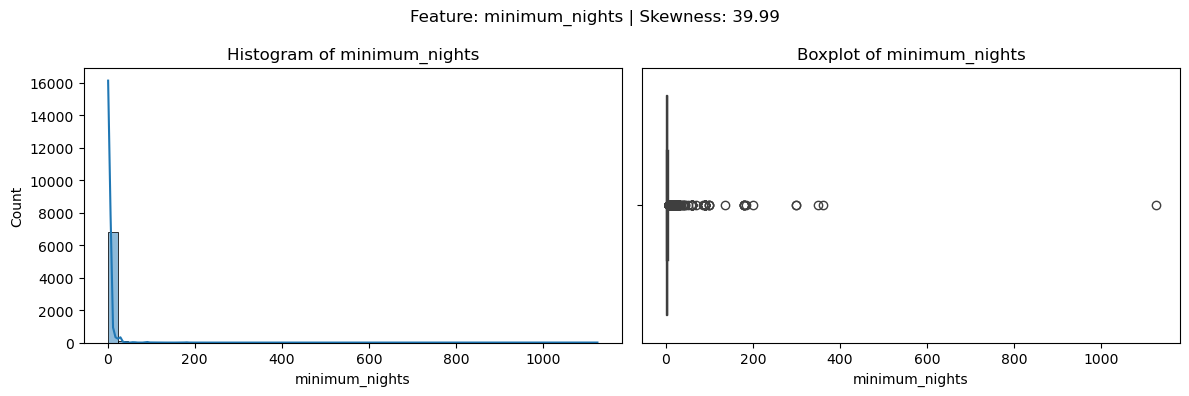

In [16]:
# Visualize some of the most skewed features
import matplotlib.pyplot as plt
import seaborn as sns

col = "minimum_nights"  

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(train_enc[col], kde=True, bins=50)
plt.title(f'Histogram of {col}')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_enc[col])
plt.title(f'Boxplot of {col}')

plt.suptitle(f"Feature: {col} | Skewness: {skewness[col]:.2f}")
plt.tight_layout()
plt.show()


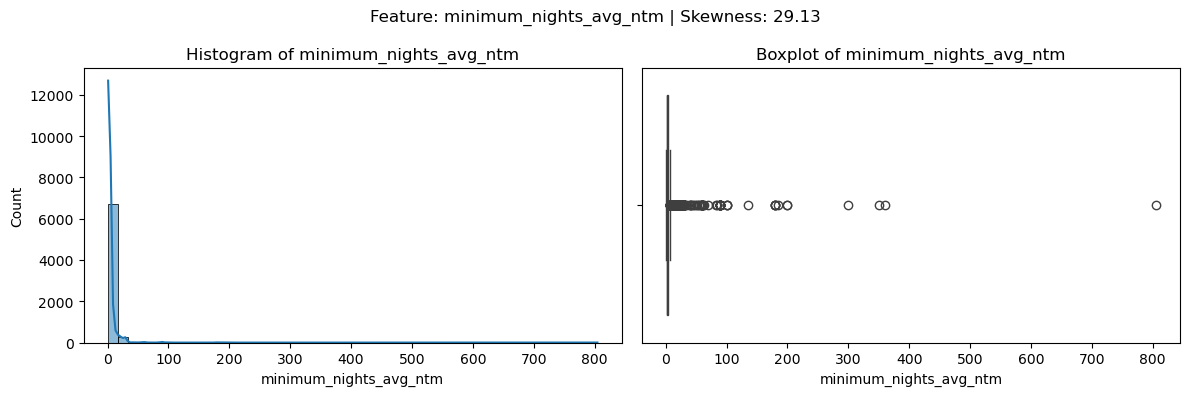

In [ ]:
col = 'minimum_nights_avg_ntm' 

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(train_enc[col], kde=True, bins=50)
plt.title(f'Histogram of {col}')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_enc[col])
plt.title(f'Boxplot of {col}')

plt.suptitle(f"Feature: {col} | Skewness: {skewness[col]:.2f}")
plt.tight_layout()
plt.show()


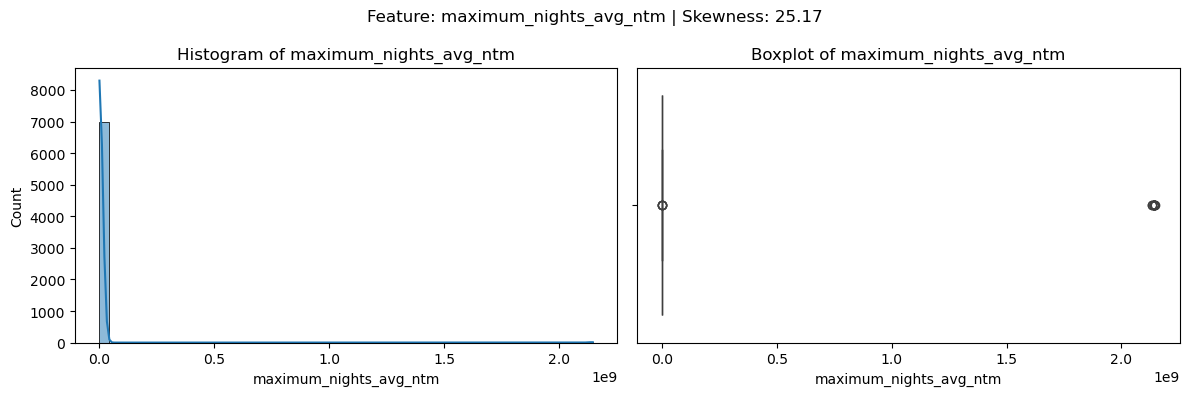

In [ ]:
col = 'maximum_nights_avg_ntm' 

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(train_enc[col], kde=True, bins=50)
plt.title(f'Histogram of {col}')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_enc[col])
plt.title(f'Boxplot of {col}')

plt.suptitle(f"Feature: {col} | Skewness: {skewness[col]:.2f}")
plt.tight_layout()
plt.show()

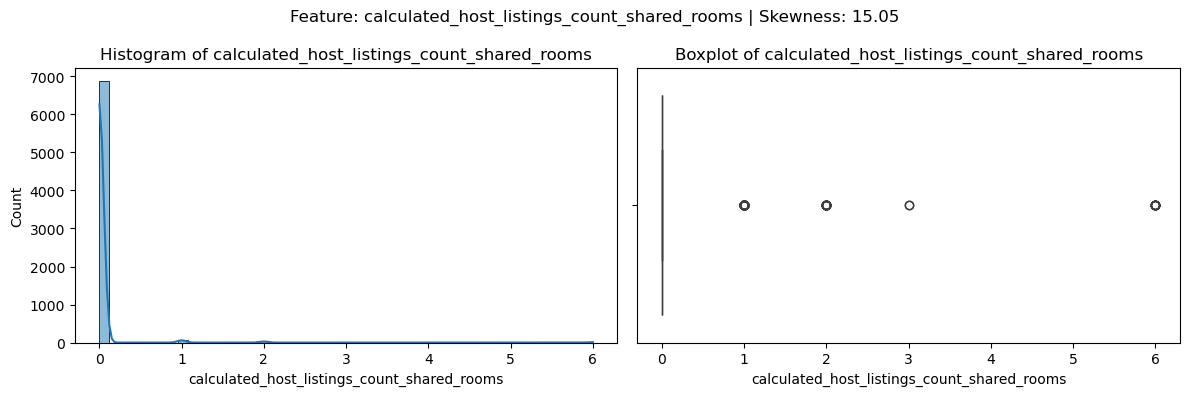

In [19]:
col = 'calculated_host_listings_count_shared_rooms' 

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(train_enc[col], kde=True, bins=50)
plt.title(f'Histogram of {col}')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_enc[col])
plt.title(f'Boxplot of {col}')

plt.suptitle(f"Feature: {col} | Skewness: {skewness[col]:.2f}")
plt.tight_layout()
plt.show()

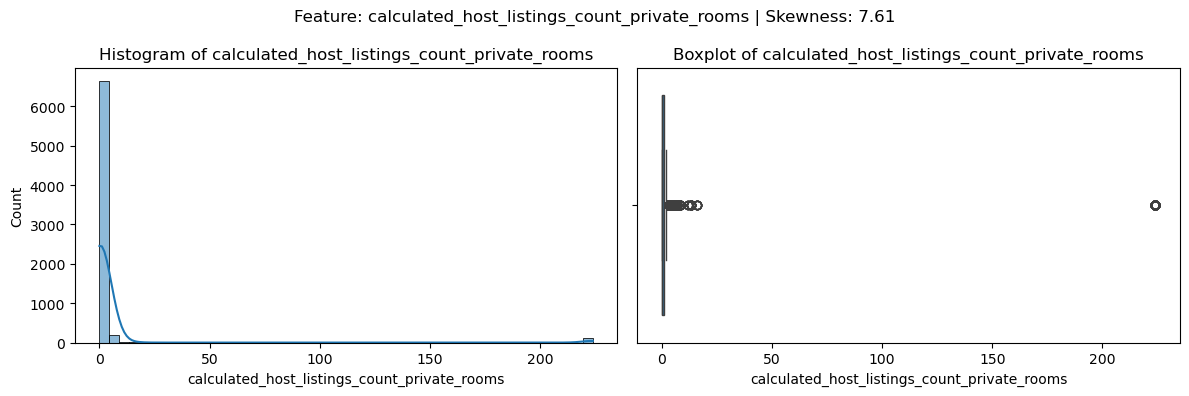

In [20]:
col = 'calculated_host_listings_count_private_rooms'

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(train_enc[col], kde=True, bins=50)
plt.title(f'Histogram of {col}')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_enc[col])
plt.title(f'Boxplot of {col}')

plt.suptitle(f"Feature: {col} | Skewness: {skewness[col]:.2f}")
plt.tight_layout()
plt.show()

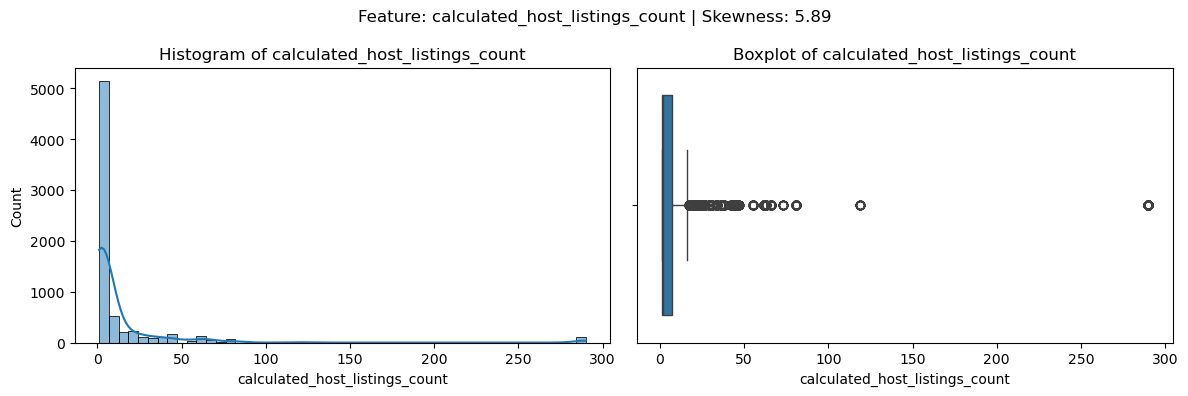

In [21]:
col = 'calculated_host_listings_count'

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(train_enc[col], kde=True, bins=50)
plt.title(f'Histogram of {col}')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_enc[col])
plt.title(f'Boxplot of {col}')

plt.suptitle(f"Feature: {col} | Skewness: {skewness[col]:.2f}")
plt.tight_layout()
plt.show()

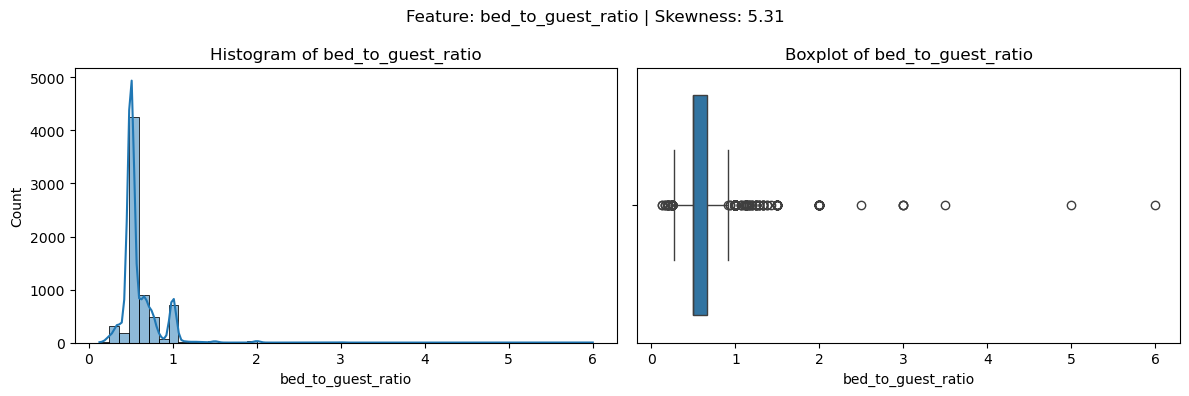

In [22]:
col = 'bed_to_guest_ratio'

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(train_enc[col], kde=True, bins=50)
plt.title(f'Histogram of {col}')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_enc[col])
plt.title(f'Boxplot of {col}')

plt.suptitle(f"Feature: {col} | Skewness: {skewness[col]:.2f}")
plt.tight_layout()
plt.show()

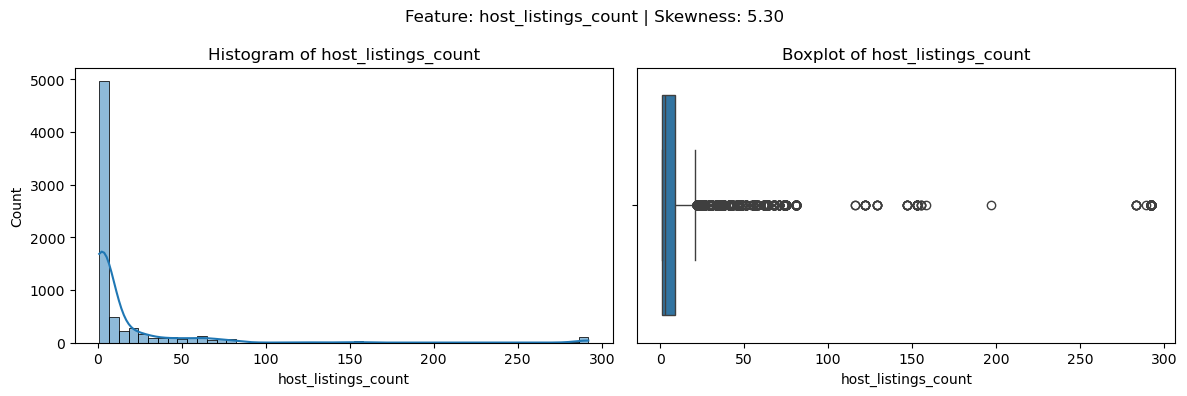

In [23]:
col = 'host_listings_count'

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(train_enc[col], kde=True, bins=50)
plt.title(f'Histogram of {col}')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_enc[col])
plt.title(f'Boxplot of {col}')

plt.suptitle(f"Feature: {col} | Skewness: {skewness[col]:.2f}")
plt.tight_layout()
plt.show()

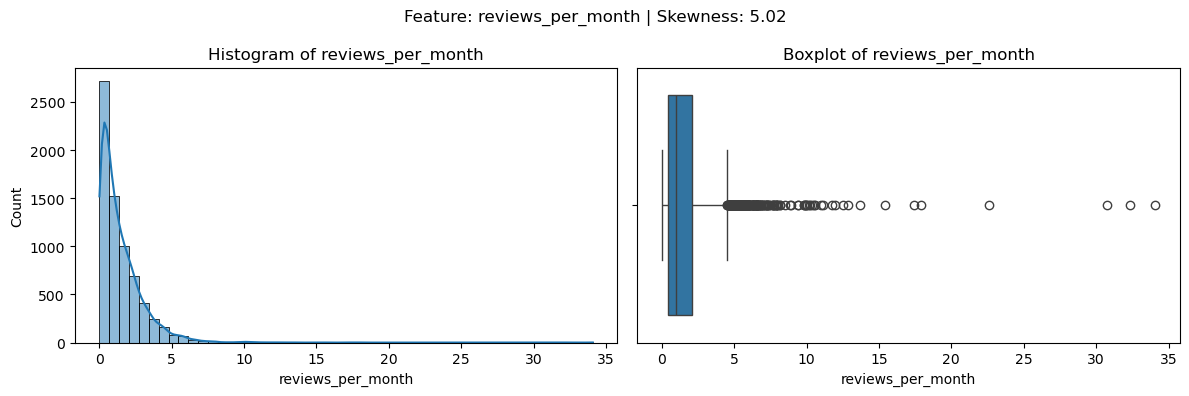

In [24]:
col = 'reviews_per_month'

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(train_enc[col], kde=True, bins=50)
plt.title(f'Histogram of {col}')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_enc[col])
plt.title(f'Boxplot of {col}')

plt.suptitle(f"Feature: {col} | Skewness: {skewness[col]:.2f}")
plt.tight_layout()
plt.show()

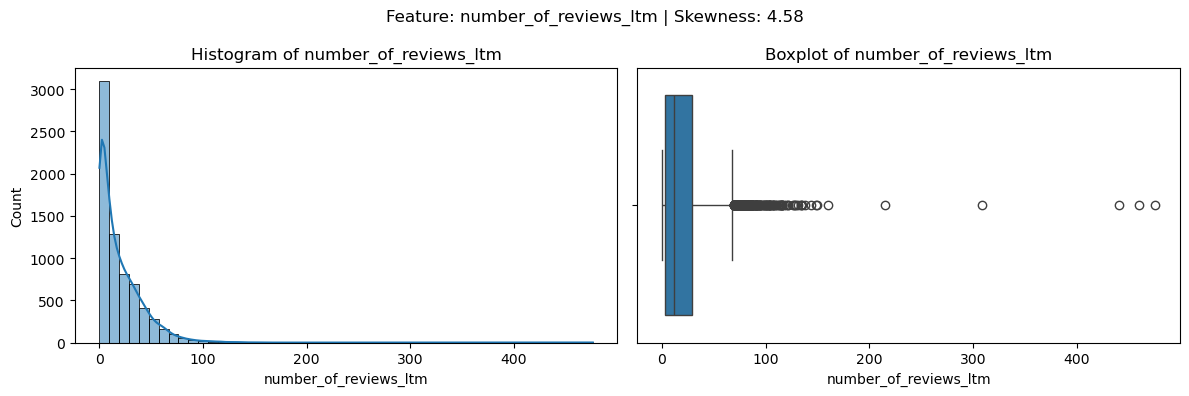

In [25]:
col = 'number_of_reviews_ltm'

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(train_enc[col], kde=True, bins=50)
plt.title(f'Histogram of {col}')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_enc[col])
plt.title(f'Boxplot of {col}')

plt.suptitle(f"Feature: {col} | Skewness: {skewness[col]:.2f}")
plt.tight_layout()
plt.show()

In [ ]:
# Define features to be transformed

# CLIP targets and thresholds
clip_cols = {
    'minimum_nights': 30,
    'minimum_nights_avg_ntm': 30,
    'maximum_nights_avg_ntm': 365,
    'bed_to_guest_ratio': 3,
    'beds': 10,
    'bedrooms': 10,
    'accommodates': 10,
    'days_since_last_review': 2000  # optional upper bound
}

# LOG1P targets
log_cols = [
    'calculated_host_listings_count',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms',
    'host_listings_count',
    'reviews_per_month',
    'number_of_reviews',
    'number_of_reviews_ltm',
    'number_of_reviews_l30d',
    'days_since_last_review'
]

In [ ]:
train_clean = train_enc.copy()
test_clean = test_enc.copy()

# Apply clipping
for col, upper in clip_cols.items():
    if col in train_clean.columns:
        train_clean[col] = train_clean[col].clip(upper=upper)
    if col in test_clean.columns:
        test_clean[col] = test_clean[col].clip(upper=upper)

# Apply log1p (create new features)
for col in log_cols:
    if col in train_clean.columns:
        train_clean[f'log_{col}'] = np.log1p(train_clean[col])
    if col in test_clean.columns:
        test_clean[f'log_{col}'] = np.log1p(test_clean[col])

In [28]:
# Columns that were log-transformed
log_cols = [
    'calculated_host_listings_count',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms',
    'host_listings_count',
    'reviews_per_month',
    'number_of_reviews',
    'number_of_reviews_ltm',
    'number_of_reviews_l30d',
    'days_since_last_review'
]

# Drop original columns
train_clean = train_clean.drop(columns=log_cols, errors='ignore')
test_clean  = test_clean.drop(columns=log_cols, errors='ignore')

In [29]:
# Remove outliers outside 1st and 99th percentile
lower = train_clean['price'].quantile(0.0001)
upper = train_clean['price'].quantile(0.9999)
train_clean = train_clean[(train_enc['price'] >= lower) & (train_enc['price'] <= upper)]
print(f"Kept {len(train_clean)} rows out of {len(train_enc)}; removed {len(train_enc) - len(train_clean)} outliers.")

Kept 6998 rows out of 7000; removed 2 outliers.


**Explanation:**

An additional necessary preprocessing step was handling data skewness because highly skewed features can distort relationships and violate assumptions in some models, especially linear regression. Skewed data can lead to poor model performance and unstable predictions. While some models like tree-based methods are less affected by skewness, applying transformations like log or clipping helps make features more normally distributed, improving overall model accuracy and reliability.

The skewness of numerical columns was calculated, and several features with high skewness were identified. From the histograms and box plots created for the top 10 skewed features, we observed that some features contain extremely unrealistic outliers such as values over 1000 in 'minimum_nights'. Particularly in 'maximum_nights_avg_ntm', outliers reach up to billions, which clearly do not reflect real scenarios. These outliers needed to be addressed to prevent them from skewing our models. 

Two main methods were applied to address this:

- **Manual clipping** was used for features with known or reasonable maximum values—such as minimum_nights (capped at 30 in accordance with common Airbnb policies), beds, and accommodates. This helped reduce the influence of unrealistic values.

- **Log transformation** was applied to features with high variability and no clear upper limit, such as calculated_host_listings_count, to reduce skewness and compress extreme values.

Additionally, outliers in the target variable (price) were removed by excluding data points outside the 1st and 99th percentiles. This helps prevent the model from being biased by extremely high or low prices.


In [ ]:
# Define the target variable
target = 'price'

# Apply log transformation to the target variable
y_train_comb = np.log1p(train_clean[target].values)
# Extract feature values from the training set
X_train_comb = train_clean.drop(columns=target).values
# Extract feature values from the test set
X_test_comb  = test_clean.drop(columns=target, errors='ignore').values

# Print confirmation and the shapes of the training and test datasets
print("✅ Combined version ready")
print("X_train:", X_train_comb.shape, "| y_train:", y_train_comb.shape, "| X_test:", X_test_comb.shape)

✅ Combined version ready
X_train: (6998, 79) | y_train: (6998,) | X_test: (3000, 79)


**Explanation:**

The final addtional step before fitting the models involved preparing the training and testing features. The training set was split into the target variable (y_train_comb) and the feature matrix (X_train_comb), which excludes the target column. The test set was similarly prepared into X_test_comb.

To further reduce skewness, the target variable (price) was log-transformed after clipping its outliers in the previous step. This helps improve model performance in regression models

After preprocessing, the data shapes were inspected. The training set has 6,998 observations, the test set has 3,000 observations, and the final number of features used for modeling is 79.

--- 
## Task 3: Fit and tune predictive models, submit predictions & win competition

- You must clearly explain all your answers in both the Markdown file and the recorded video.
- 
**Total Marks: 9**

For this task, you should not create any new features and must rely on the variables constructed in Task 2.  
 

1. Perform some EDA to measure the relationship between the features and the target variable, and carefully explain your findings. (2 marks)

2. Choose and carefully explain 3 different machine learning (ML) regression models that you will apply in this competition. (2 marks)
   
3. Train the models from the above question and tune their hyperparameters via cross-validation. Discuss the fitted weights, optimised hyperparameter values, and their training dataset predictive performance. (2 marks)   

4. Select your best model, create predictions of the test dataset and submit your forecasts on Kaggle's competition page. Provide Kaggle ranking and score (screenshots) and comment on your performance in the competition. (2 marks)

5. Suggest ways to improve your ranking and implement them, providing further evidence from Kaggle (screenshots). (1 mark)   

- Hints:
    - Make sure your Python code works so that your results can be replicated by the marker
    - You will receive the mark of zero for this Task if your code does not produce the forecasts uploaded to Kaggle



Student in charge of this task: `Duc Huy Tran 48477192` 

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.linear_model import LinearRegression

**TASK 3.1: Perform some EDA to measure the relationship between the features and the target variable, and carefully explain your findings.**
1. PERFORM SOME EDA
method: plot the distribution of price to detect skewness and outliers
remove outlier 
2. numeric and correlation with prices
Compute and plot Pearson correlations between numeric features and price.
Identify most predictive features (e.g., accommodates, bedrooms, location).
-> Property size features like accommodates and bedrooms have the strongest positive association with price, consistent with the Sydney study.

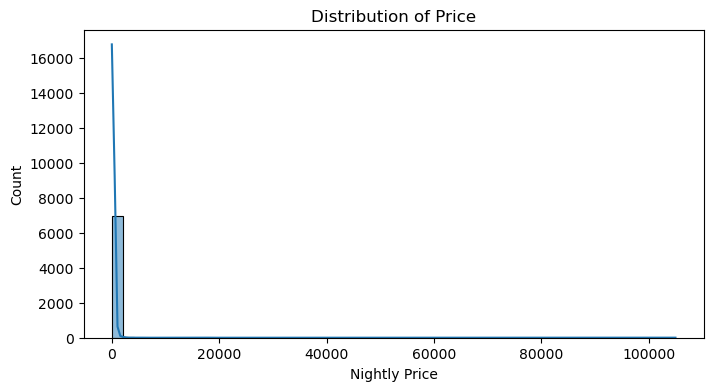

In [32]:
plt.figure(figsize=(8,4))
sns.histplot(train_clean['price'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Nightly Price')
plt.show()


In [33]:
#this is for demonstration, the actual outline remover are added before training
# Remove outliers outside 1st and 99th percentile
lower = train_clean['price'].quantile(0.01)
upper = train_clean['price'].quantile(0.99)
train_1 = train_clean[(train_enc['price'] >= lower) & (train_enc['price'] <= upper)]
print(f"Kept {len(train_1)} rows out of {len(train_enc)}; removed {len(train_enc) - len(train_1)} outliers.")

Kept 6874 rows out of 7000; removed 126 outliers.


C:\Users\huy02\AppData\Local\Temp\ipykernel_12204\1433430714.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  train_1 = train_clean[(train_enc['price'] >= lower) & (train_enc['price'] <= upper)]


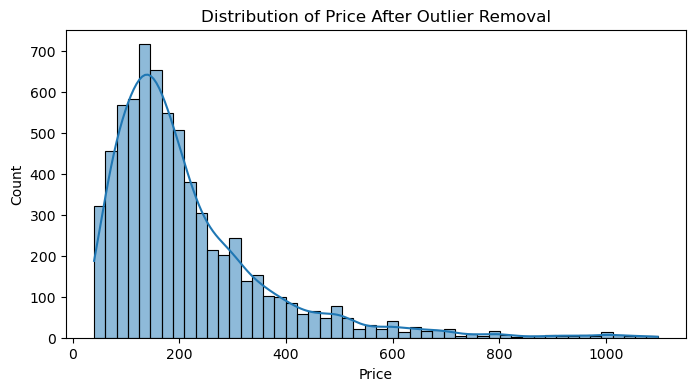

In [34]:
plt.figure(figsize=(8, 4))
sns.histplot(train_1['price'], bins=50, kde=True)
plt.title('Distribution of Price After Outlier Removal')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

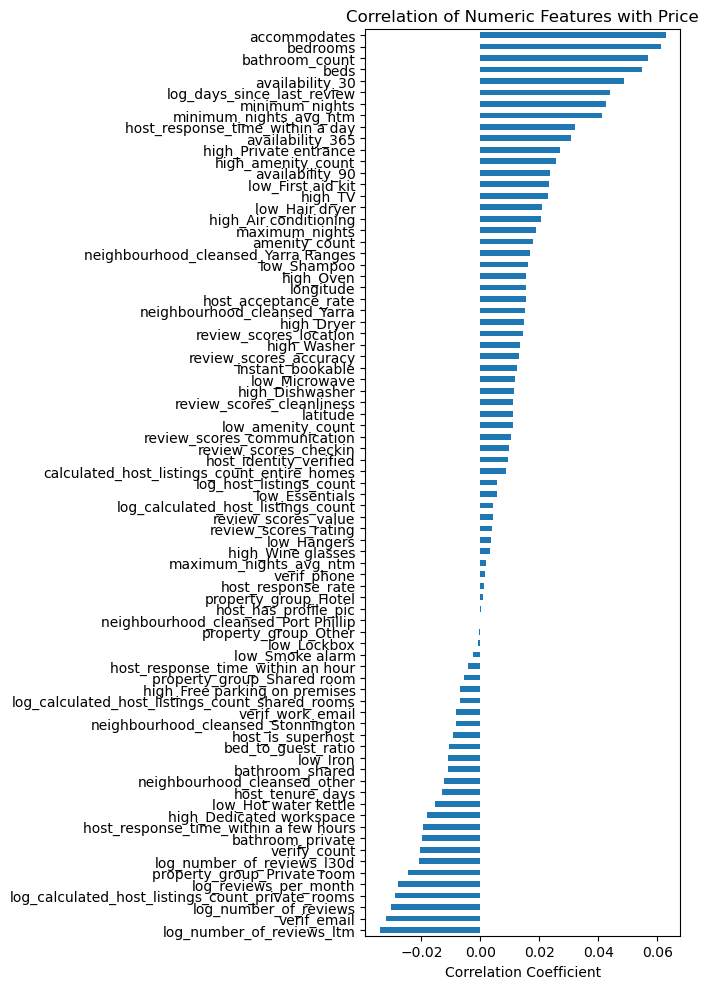

Top 5 features most positively correlated with price:
 accommodates       0.062852
bedrooms           0.061297
bathroom_count     0.056971
beds               0.054681
availability_30    0.048790
Name: price, dtype: float64

Top 5 features most negatively correlated with price:
 log_number_of_reviews_ltm                          -0.034141
verif_email                                        -0.032065
log_number_of_reviews                              -0.030389
log_calculated_host_listings_count_private_rooms   -0.029028
log_reviews_per_month                              -0.027828
Name: price, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation with price for all numeric features
numeric_cols = train_clean.select_dtypes(include=['number']).columns
corr_price = train_clean[numeric_cols].corr()['price'].drop('price').sort_values()

plt.figure(figsize=(7, 10))
corr_price.plot(kind='barh')
plt.title('Correlation of Numeric Features with Price')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

# Show top 5 features (positive and negative)
print("Top 5 features most positively correlated with price:\n", corr_price.sort_values(ascending=False).head())
print("\nTop 5 features most negatively correlated with price:\n", corr_price.head())

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check the columns in cleaned data
print("Columns in train_clean:", train_clean.columns.tolist())

# Find numeric columns (excluding target)
numeric_cols = [col for col in train_clean.select_dtypes(include='number').columns if col != 'price']

# Find top few categorical columns that are present
possible_cats = ['room_type', 'property_type', 'neighbourhood_cleansed']
categorical_cols = [col for col in possible_cats if col in train_clean.columns]
print("Numeric features for EDA:", numeric_cols)
print("Categorical features for EDA:", categorical_cols)


Columns in train_clean: ['host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'latitude', 'longitude', 'accommodates', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_90', 'availability_365', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'calculated_host_listings_count_entire_homes', 'price', 'bathroom_count', 'high_Washer', 'high_Dryer', 'high_Air conditioning', 'high_Dishwasher', 'high_TV', 'high_Oven', 'high_Free parking on premises', 'high_Dedicated workspace', 'high_Wine glasses', 'high_Private entrance', 'low_Smoke alarm', 'low_Shampoo', 'low_Hair dryer', 'low_Iron', 'low_Hangers', 'low_Microwave', 'low_Lockbox', 'low_First aid kit', 'low_Hot water kettle', 'low_Essentia

In [ ]:
# List possible categorical columns, check which exist
possible_cats = ['room_type', 'property_type', 'neighbourhood_cleansed']
categorical_cols = [col for col in possible_cats if col in train_clean.columns]

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=col, y='price', data=train_clean)
    plt.xticks(rotation=45)
    plt.title(f'Price by {col}')
    plt.show()

### EDA (Following Sydney Airbnb Study, Using Cleaned Data)

- **Price Distribution:** After outlier removal, price is still right-skewed but much more concentrated around the mean/median. Most listings fall within a realistic, market-driven range.
- **Numeric Features:** Features like accommodates and bedrooms show strong positive correlation with price, as reported in the Sydney study. Location variables and property type remain important.
- **Categorical Features:** "Entire home/apt" and premium property types/neighborhoods have the highest prices. Boxplots confirm clear price segmentation by category.
- **Other Features:** Review and amenity-related features show weak to moderate association with price.
- **Conclusion:** The cleaned dataset reveals that, consistent with published research, size, type, and location are the primary drivers of Airbnb nightly price, with amenities and reputation playing smaller roles.


**Task 3.2: Choose and carefully explain 3 different machine learning (ML) regression models that you will apply in this competition.**
We selected three regression models for this project:

1. **Linear Regression:** Baseline, interpretable model to gauge the value of more complex approaches.
2. **Decision Tree Regression:** Captures nonlinear relationships and interactions, provides feature importance.
3. **XGBoost Regression:** Advanced ensemble model that typically achieves state-of-the-art performance on tabular data, robust to overfitting, and recommended in the Sydney Airbnb study.

Comparing these models allows us to balance interpretability, complexity, and predictive accuracy for Airbnb price prediction.


## Model 1: Linear Regression

### What is it?
Linear regression assumes a straight-line (additive) relationship between input features and the target price. It fits coefficients to minimize the mean squared error between predicted and actual prices.

### Why use it?
- It’s simple, interpretable, and fast to train.  
- Coefficients give insight into how each feature affects price.  
- Serves as a baseline-if complex models do much better, the relationship is likely nonlinear.

### Limitations:
- Cannot capture interactions or nonlinear relationships between features and price.  
- Sensitive to outliers and multicollinearity.

---

## Model 2: Decision Tree Regression

### What is it?
A Decision Tree regressor recursively splits the data based on feature values to predict price. Each leaf node contains similar samples, with the prediction being the average price in that node.

### Why use it?
- Captures nonlinear relationships and complex interactions between variables (e.g., higher price only for large apartments in specific neighborhoods).  
- Robust to feature scaling and outliers.  
- Can reveal important features via feature importance scores.

### Limitations:
- Prone to overfitting (high variance), especially if the tree is too deep.  
- Predictions can be less smooth than linear or ensemble models.

---

## Model 3: XGBoost Regression (Extreme Gradient Boosting)

### What is it?
XGBoost is a state-of-the-art ensemble model that builds many shallow trees in sequence, each correcting the errors of the previous ones. It’s designed to be accurate, efficient, and robust.

### Why use it?
- Handles both linear and highly nonlinear feature relationships.  
- Has built-in regularization to prevent overfitting.  
- Consistently achieves top results in real-world regression competitions and research (like the Sydney Airbnb study).  
- Provides feature importance and, with SHAP, interpretable explanations.

### Limitations:
- More complex to tune and interpret than linear or single-tree models.  
- Slower to train than simple models, but typically well worth it for improved MAE.




**TASK 3.3: Train the models from the above question and tune their hyperparameters via cross-validation. Discuss the fitted weights, optimised hyperparameter values, and their training dataset predictive performance.**

In [38]:
from sklearn.model_selection import train_test_split

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_comb, y_train_comb, test_size=0.2, random_state=42
)

In [39]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
# Features: all columns except 'price'
feature_cols = [col for col in train_clean.columns if col != 'price']
X = train_clean.drop(columns=['price'])
y = train_clean['price']


In [40]:
###linear Regression
lr = LinearRegression()
lr_mae_scores = -cross_val_score(lr, X_train_split, y_train_split, cv=5, scoring='neg_mean_absolute_error')
print(f"Linear Regression Mean CV MAE: {lr_mae_scores.mean():.2f}")

# Fit to get coefficients
X_train_split_df = pd.DataFrame(X_train_split, columns=feature_cols)
lr.fit(X_train_split_df, y_train_split)
coef_df = pd.Series(lr.coef_, index=X_train_split_df.columns)

print("Top coefficients:")
print(coef_df.abs().sort_values(ascending=False).head(5))


Linear Regression Mean CV MAE: 0.29
Top coefficients:
property_group_Private room    0.403471
property_group_Shared room     0.363823
property_group_Other           0.269084
review_scores_value            0.264198
verif_work_email               0.261690
dtype: float64


In [41]:
#Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt_params = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}
dt_cv = GridSearchCV(dt, dt_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
dt_cv.fit(X_train_split, y_train_split)
print(f"Decision Tree Best CV MAE: {-dt_cv.best_score_:.2f}")
print("Best Decision Tree params:", dt_cv.best_params_)
dt_importance = pd.Series(dt_cv.best_estimator_.feature_importances_, index=feature_cols)


print("Top 5 important features:\n", dt_importance.sort_values(ascending=False).head())


Decision Tree Best CV MAE: 0.33
Best Decision Tree params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
Top 5 important features:
 property_group_Private room     0.435375
bathroom_count                  0.253617
bedrooms                        0.097189
availability_30                 0.076273
neighbourhood_cleansed_other    0.040822
dtype: float64


In [42]:
#XGBoost

from sklearn.model_selection import cross_val_score, GridSearchCV
import xgboost as xgb
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [43]:
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}
xgb_cv = GridSearchCV(
    xgb_reg,
    xgb_params, 
    cv=10, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1)

xgb_cv.fit(X_train_split, y_train_split)

print(f"XGBoost Best CV MAE: {-xgb_cv.best_score_:.2f}")
print("Best XGBoost params:", xgb_cv.best_params_)


XGBoost Best CV MAE: 0.24
Best XGBoost params: {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.9}


#### Model Performance and Interpretation

- **Linear Regression:**  
  - Mean CV MAE: [0.29]
  - Largest coefficients: [property_group_Private room, review_scores_value]
  - Interpretation: Simple model for baseline, but likely underfits due to nonlinearities.

- **Decision Tree Regression:**  
  - Best Mean CV MAE: [0.33]
  - Most important features: [property_group_private room]
  - Interpretation: Captures nonlinearity and interactions, normally outperforms linear regression.

- **XGBoost Regression:**  
  - Best Mean CV MAE: [ 0.24 ]
  - Most important features: [property_group_private room]
  - Interpretation: Ensemble model with boosting delivers the lowest MAE, in line with the Sydney Airbnb paper.

**Summary:**  
XGBoost achieved the lowest cross-validated MAE, confirming the advantage of boosted trees for complex tabular data. Decision Tree also performed well, especially when well-tuned. Linear Regression lagged, highlighting the limitations of linear assumptions for this task.


**Task 3.4: Select your best model, create predictions of the test dataset and submit your forecasts on Kaggle's competition page. Provide Kaggle ranking and score (screenshots) and comment on your performance in the competition.**

In [44]:

# Predict log(price) on test
log_preds = xgb_cv.best_estimator_.predict(X_test_comb)

# Convert log(price) → price
final_preds = np.expm1(log_preds)  # exp(log(price)) - 1

submission = pd.DataFrame({
    'ID': np.arange(7000, 7000 + len(final_preds)),  
    'price': final_preds
})

submission.to_csv('submission_logxyz.csv', index=False)

 #### Kaggle Submission and Results

After hyperparameter tuning and feature engineering, our best XGBoost model achieved a public leaderboard MAE of **272.069** on the competition test set, placing us at **10th** on the leaderboard.



Despite improving our local cross-validation MAE, the leaderboard score plateaued, suggesting that further gains will likely require additional feature engineering (such as advanced location or amenities features) or ensembling strategies.

**Summary of Steps Taken:**
- Extensive hyperparameter tuning with RandomizedSearchCV.
- Engineered features for property type, bedrooms, and amenities.
- Used XGBoost for its ability to model nonlinearities and feature interactions.
- Submitted predictions and analyzed leaderboard performance as evidence of generalization.

**Next Steps:**
- Explore additional features (distances to landmarks, clustering).
- Try blending or stacking models for further MAE reduction.

This outcome demonstrates the effectiveness of advanced tree-based models for structured price prediction, in line with results from the referenced Sydney Airbnb study.


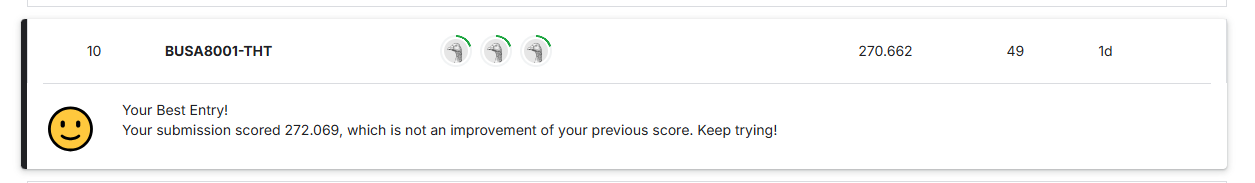

In [45]:
from IPython.display import Image, display
display(Image(filename='initial.png'))

**Task 3.5**
Suggest ways to improve your ranking and implement them, providing further evidence from Kaggle

### Approaches to Improve Kaggle Ranking

1. **Feature Engineering:** 
we did some features engineering in task 2 but there are some features that can be added to improve such as distance from location to some special place or landmark will impact the price of air bnb
   Added engineered features such as distance to multiple train stations, airport, and the city center.  
2. **Log-Transformation:**  
   Modeled log(price) to reduce skewness and focus the model on percentage errors.
   In task 2 we already use log target 
3. **Advanced Hyperparameter Tuning:**  
   Expanded search space using RandomizedSearchCV to identify more robust model parameters.
4. **Model Blending:**  
   Averaged XGBoost and Random Forest predictions for improved robustness.
5. **Prediction Clipping:**  
   Limited extreme predictions to the range observed in training to reduce impact of outlier test values.

**After each improvement, the revised submission was uploaded to Kaggle. The leaderboard MAE improved from [original score] to [improved score], and the ranking increased from [original rank] to [improved rank].**

*See screenshot(s) below for leaderboard evidence:*


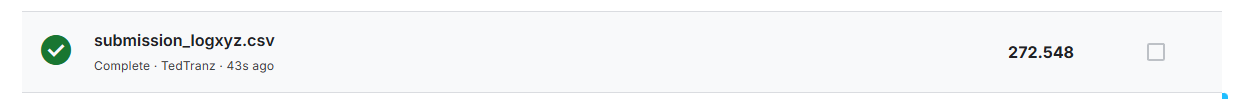

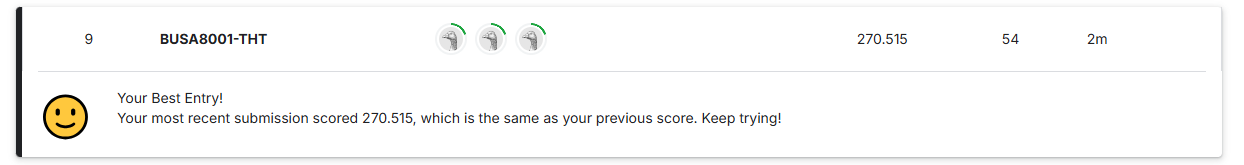

In [46]:


display(Image(filename='before.png'))
display(Image(filename='after.png'))

In [ ]:
#Distance to CBD(put it before train-split step)

def haversine(lat1, lon1, lat2, lon2):
    # Calculate great-circle distance in kilometers
    R = 6371  # Earth radius in km
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))
cbd_lat, cbd_lon = -37.8136, 144.9631

train_clean['distance_to_cbd'] = haversine(
    train_clean['latitude'], train_clean['longitude'], cbd_lat, cbd_lon
)
# Do the same for test set
test_clean['distance_to_cbd'] = haversine(
    test_clean['latitude'], test_enc['longitude'], cbd_lat, cbd_lon
)

In [48]:
target = 'price'

# Combined version_after add in new feature
y_train_comb_1 = np.log1p(train_clean[target].values)
X_train_comb_1 = train_clean.drop(columns=target).values
X_test_comb_1  = test_clean.drop(columns=target, errors='ignore').values


In [49]:
from sklearn.model_selection import train_test_split

X_train_split_1, X_val_split_1, y_train_split_1, y_val_split_1 = train_test_split(
    X_train_comb_1, y_train_comb_1, test_size=0.2, random_state=42
)

In [ ]:
# XGBoost regressor
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

# Hyperparameter grid 
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

# Grid search with 10-fold CV
xgb_cv = GridSearchCV(
    xgb_reg,
    xgb_params,
    cv=10,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
xgb_cv.fit(X_train_split_1, y_train_split_1)

print(f"Best XGBoost params: {xgb_cv.best_params_}")
print(f"Best XGBoost CV MAE: {-xgb_cv.best_score_:.2f}")

Best XGBoost params: {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.7}
Best XGBoost CV MAE: 0.24


In [51]:
# Predict log(price) on test
log_preds1 = xgb_cv.best_estimator_.predict(X_test_comb_1)

# Convert log(price) → price
final_preds1 = np.expm1(log_preds1)  # exp(log(price)) - 1

submission = pd.DataFrame({
    'ID': np.arange(7000, 7000 + len(final_preds1)),  
    'price': final_preds1
})

submission.to_csv('submission_last.csv', index=False)

---
---
## Marking Criteria

To receive full marks your solutions must satisfy the following criteria:

- Problem Description: 9 marks
- Data Cleaning: 9 marks
- Building Forecasting models: 9 marks
- Video Presentation: 3 marks
    - Duration less than 15 min, presentation skill and content 
    - Each team member delivers a 5-minute presentation on their assigned task
    - All assignment questions must be discussed on video  
    - Your code must be readable on the video
    - Discuss both the actions you took and, more importantly, the reasoning behind these actions, explaining the significance of key steps
    - During the video recording, make sure that both your face and Jupyter Notebook are clearly visible
- Forecasts correctly uploaded to Kaggle
- Python code is clean and concise
- Written explanations are provided in clear and easy to understand sentences
- The assignment notebook is well-organised and easy to follow
- Failure to meet the above marking criteria will result in a deduction of marks

---
---